#create input-target pairs
The last step before we create vector embeddings is to create input-target pairs

#What do these input-target pairs look like
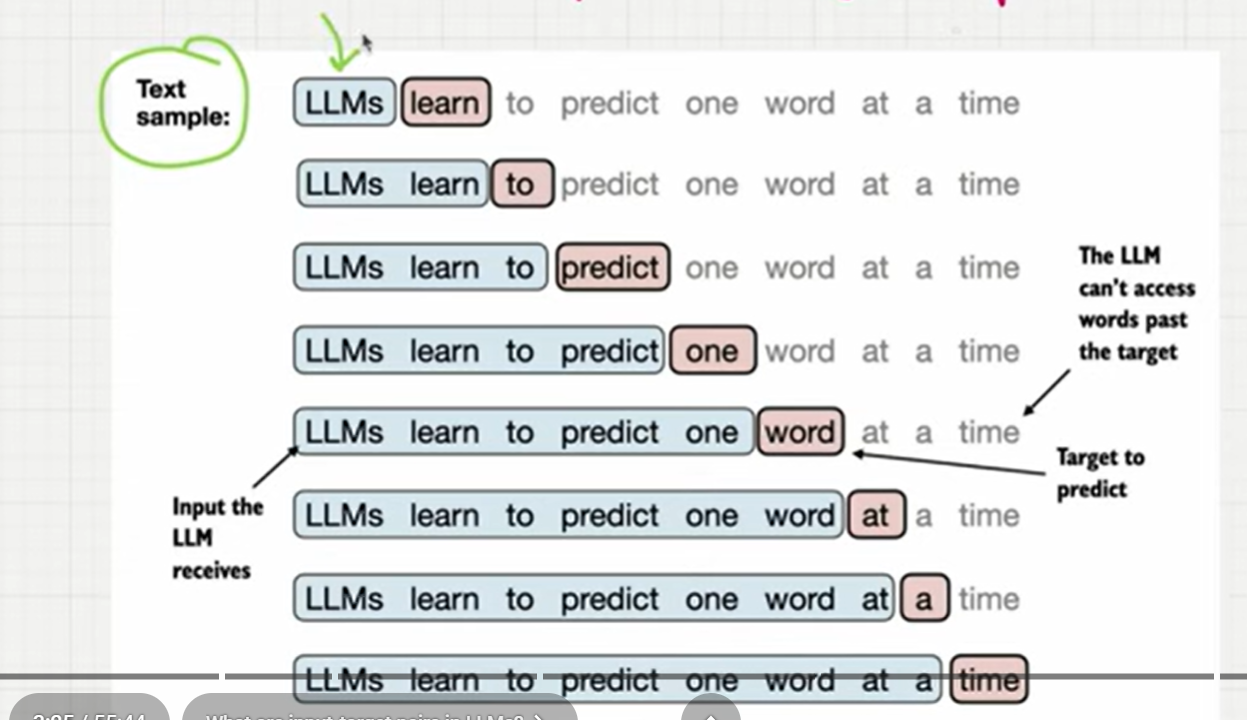


# Given a text example
extract input bloacks as subsamples
that serve as input to the LLM

The LLM prediction tasks during training is to predict the next word that follows the input block

During training, we mask out all words that are past to the target




In [ ]:
! pip3 install tiktoken

In [ ]:
import importlib
import tiktoken

print("tiktoken version:", importlib.metadata.version("tiktoken"))

tiktoken version: 0.12.0


In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")

#
In this section we implement a data loader that fetches the input-target pairs using a sliding window approach.
To get started, we will first tokenize the whole The Verdict short story we worked with earlier using the BPE tokenizer introduced in the previous section:

In [ ]:
with open("/content/the-verdict.txt","r",encoding="utf-8") as f:
  raw_text = f.read()
enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


Executing the code above will return 5145, the total number of tokens in the training set after applying the BPE tokenizer

Next, we remove the first 50 tokens from the dataset for demonstration purposes as it results in a slightly more interesting text passage in the next steps:



In [ ]:
enc_sample = enc_text[50:]

One of the easiest and most intutive ways to create the input-target pairs for the next prediction task is to create two variables x and y, where x contains the input tokens and y contains the targets which are the inputs shifted by 1:

The context size determines how many tokens are included in the input

In [ ]:
context_size = 4 # lenght of the input
#the context size of 4 means that the model is trained to look at a sequence of 4 words (or tokens )
# to predict the next word in the sequence
# the input x is the first 4 tokens [1,2,3,4] and target y is the next 4 tokens [2,3,4,5]
x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]
print(f"x:{x}")
print(f"y: {y}")

x:[290, 4920, 2241, 287]
y: [4920, 2241, 287, 257]


Processing the inputs along with the targets, which are the inputs shifted by one position, we then created the next-word prediction tasks as follows


In [ ]:
for i in range(1,context_size+1):
  context = enc_sample[:i]
  desired = enc_sample[i]
  print(context , "->" ,desired)


[290] -> 4920
[290, 4920] -> 2241
[290, 4920, 2241] -> 287
[290, 4920, 2241, 287] -> 257


Everything left of the arrow (-->) refers to the input an LLM would receive, and the token ID on the right of the arrow represents the target token ID that the LLM is supposed to predict

For Illustations purpose let repeat the previous code, but conver the token IDs into text

In [ ]:
for i in range(1,context_size+1):
  context = enc_sample[:i]
  desired = enc_sample[i]
  print(tokenizer.decode(context), "-->", tokenizer.decode([desired]))

 and -->  established
 and established -->  himself
 and established himself -->  in
 and established himself in -->  a


We have now create the input-target pairs we can turn into use for the LLM traning in upcoming chapters

There's only one more task before we can turn the tokens into embeddings: implement an efficient data loader that iterates over the input dataset and reutrn the inputs and targets as PyTorch tensors, which can be thought of as multidimensional arrays

In particular, we are interested in returning two tensors: an input tensor containing the text that the LLM sees and a target tensor that includes the targets for the LLM to predict,

#Implementing a Data Loader
for the efficient data loader implementation, we will use PyTorch built in dataset and dataloader classes
1. Tokenize the entire text

2. Use a sliding window to chunk the book into overlapping sequences of max length

3. Return the total number of rows in the dataset

4. Return a single row from the dataset

In [ ]:
import torch

In [ ]:
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
  def __init__(self,txt,tokenizer,max_length, stride):
    self.input_ids = []
    self.target_ids = []
    token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
    # use a sliding window to chunk the book into overlapping sequences of max length
    for i in range(0,len(token_ids)-max_length,stride):
      input_chunk = token_ids[i:i+max_length]
      target_chunk = token_ids[i+1:i+max_length+1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))
  def __len__(self):
    return len(self.input_ids)
  def __getitem__(self,idx):
    return self.input_ids[idx],self.target_ids[idx]


GPTDatasetV1 class in listing 2.5 based on the PyTorch Dataset class. It defines how individual rows are fetched from the dataset.

Each row consists of a number of token IDs (based on max length) assigned to a input_chunk tensor

The target_chunk tensor contains the corresponding targets

I reccomend reading on to see how the data returned from this dataset looks like when dataset with a PyTorch DataLoader -- this will bring additional intution and clarity

The following code will use the GPTDatasetV1 to load the inputs in batches via a Pytorch DataLoader

Step1: Intialize the tokenizer

Step2: Create Dataset

Step3: drop_last=True drops the last batch if it is shorter than the specified batch_size to prevent loss spikes during training

Step4: The number of CPU processes to use for preprocessing


In [ ]:
def create_datasetloader_v1(txt,batch_size=4,
                            max_length=256,stride=128, shuffle=True,
                            drop_last=True, num_workers=0):
  #intialize the tokenizer
  tokenizer = tiktoken.get_encoding("gpt2")
  # create dataset
  dataset = GPTDatasetV1(txt,tokenizer,max_length,stride)
  # create a dataloader
  dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )
  return dataloader




Lets test dataloader with a batchsie of 1 for an LLM with context size of 4
this will develop an intution of how the GPTdatasetV1 class and create dataloader v1 function work together

In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

Convert dataloader into a Python iterator to fetch the next entry via Python's built-in next() function

In [ ]:
import torch
print("Pytorch version:", torch.__version__)


Pytorch version: 2.8.0+cu126


In [ ]:
dataloader = create_datasetloader_v1(raw_text,batch_size=1,max_length=4, stride=1,shuffle=False)
data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


The first_batch variable contains two tensors: the first tensor stores the input token ID and the second tensor stores the target token IDs.

Since the max_length is set to 4, each of the two tensors contains 4 token IDs  

Note that an input size of 4 is relatively small and only chosen for illustration purposes. It is common to train LLMs with input sizes of at least 256.


To illustrate the meaning of stride=1, let's fetch another batch from this dataset:

In [ ]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[ 367, 2885, 1464, 1807]]), tensor([[2885, 1464, 1807, 3619]])]


if we compare the first and the second batch, we can see that the second batch's token IDs are shifted by one position compared to the first batch.

For example, the second ID in the first batch's input is 367, which is the first ID of the second batch's input.

The stride setting dictates the number of positions the inputs shift across batches, emulating a sliding window approach

Batch sizes of 1, such as we have samples from the data loader so far, are useful for illustration purposes.

if you previous experience with deep learning, you may know that small batches require less memory during traning but lead to more noisy model updates

Just like in regular deep learning, the batch size is a trade-off and hyperparamer to experiment with when traning LLMs

Before we move on to the two final sections of this chapter that are focused on creating vectors from the token IDs, let's have a brief look at how we can use the data loader to sample with a batch size greater than 1:

In [ ]:
dataloader = create_datasetloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=True)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n",targets)

Inputs:
 tensor([[24818,   417,    12, 12239],
        [  314,  3114,   379,   262],
        [ 2156,   286,  4116,    13],
        [  866,   262,  2119,    11],
        [ 3363,    11,   340,   373],
        [  198,     1,    40,  2900],
        [  465, 14475,    13,   198],
        [ 3081,   286,  2045,  1190]])

Targets:
 tensor([[  417,    12, 12239,   438],
        [ 3114,   379,   262, 50085],
        [  286,  4116,    13,   679],
        [  262,  2119,    11, 12225],
        [   11,   340,   373,   314],
        [    1,    40,  2900,   736],
        [14475,    13,   198,   198],
        [  286,  2045,  1190,  4119]])


Note that we increase the stride to 4. This is to utilize the data set fully (we don't skip a single word) but also avoid any overlap between the batches, since more overlap could lead to increased overfitting.

#Create token embeddings

Lets illustrate how the token ID to embedding vector conversion works with hands on example. suppose we have the following four input tokens with IDs 2,3,5, and 1:

#quick fox is in the house
arrage in the ascending order
quick is 4 , fox is 0 , is is 3, in is 2, the is 5 and house i 1

In [ ]:
input_ids = torch.tensor([2,3,5,1])

For the sake of simplicity and illustration purposes, suppose we have a small vocabulary of only 6 words (instead of the 50,257 words in the BPE tokenizer vocabulary), and we want to create embeddings of size 3 (in GPT-3 the embedding size is 12,288 dimensions):

Usinf the vocab_size and output_dim , we can instantiate an embedding layer in Pytorch, setting the random seed to 123 for reproducibility purposes


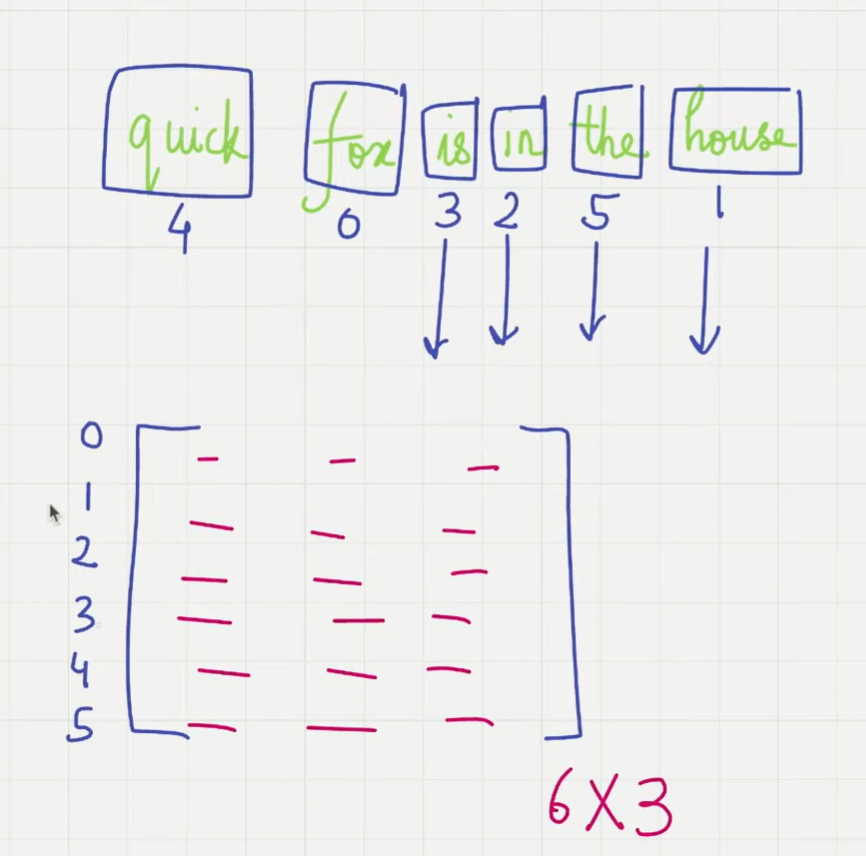

In [ ]:
vocab_size = 6
output_dim = 3
torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size,output_dim)
embedding_layer

Embedding(6, 3)

In [ ]:
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


We can see that the weight matrix of the embedding layer contains small, random values, these values are optimized during LLM training as part of the LLM optimization itself, as we will see in upcoming chapters. Moreover, we can see that the weight matrix has six rows and three columns. There is one row for each of the six possible tokens in the vocabulary. And there is one column for each of the three embedding dimensions.

After we instantiated the embedding layer, lets now apply it to a token ID to obtain the embedding vector


In [ ]:
print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


If we compare the embedding vector for token ID 3 to the previous embedding matrix, we see that it is identical to the 4th row (Python starts with a zero index, so it's the row corresponding to index 3). In other words, the embedding layer is essentially a look-up operation that retrieves rows from the embedding layer's weight matrix via a token ID.

Previously, we have seen how to convert a single token ID into a three-dimensional embedding vector. Let's now apply that to all four input IDs we defined earlier (torch.tensor([2, 3, 5, 1])):

In [ ]:
print(embedding_layer(input_ids))


tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


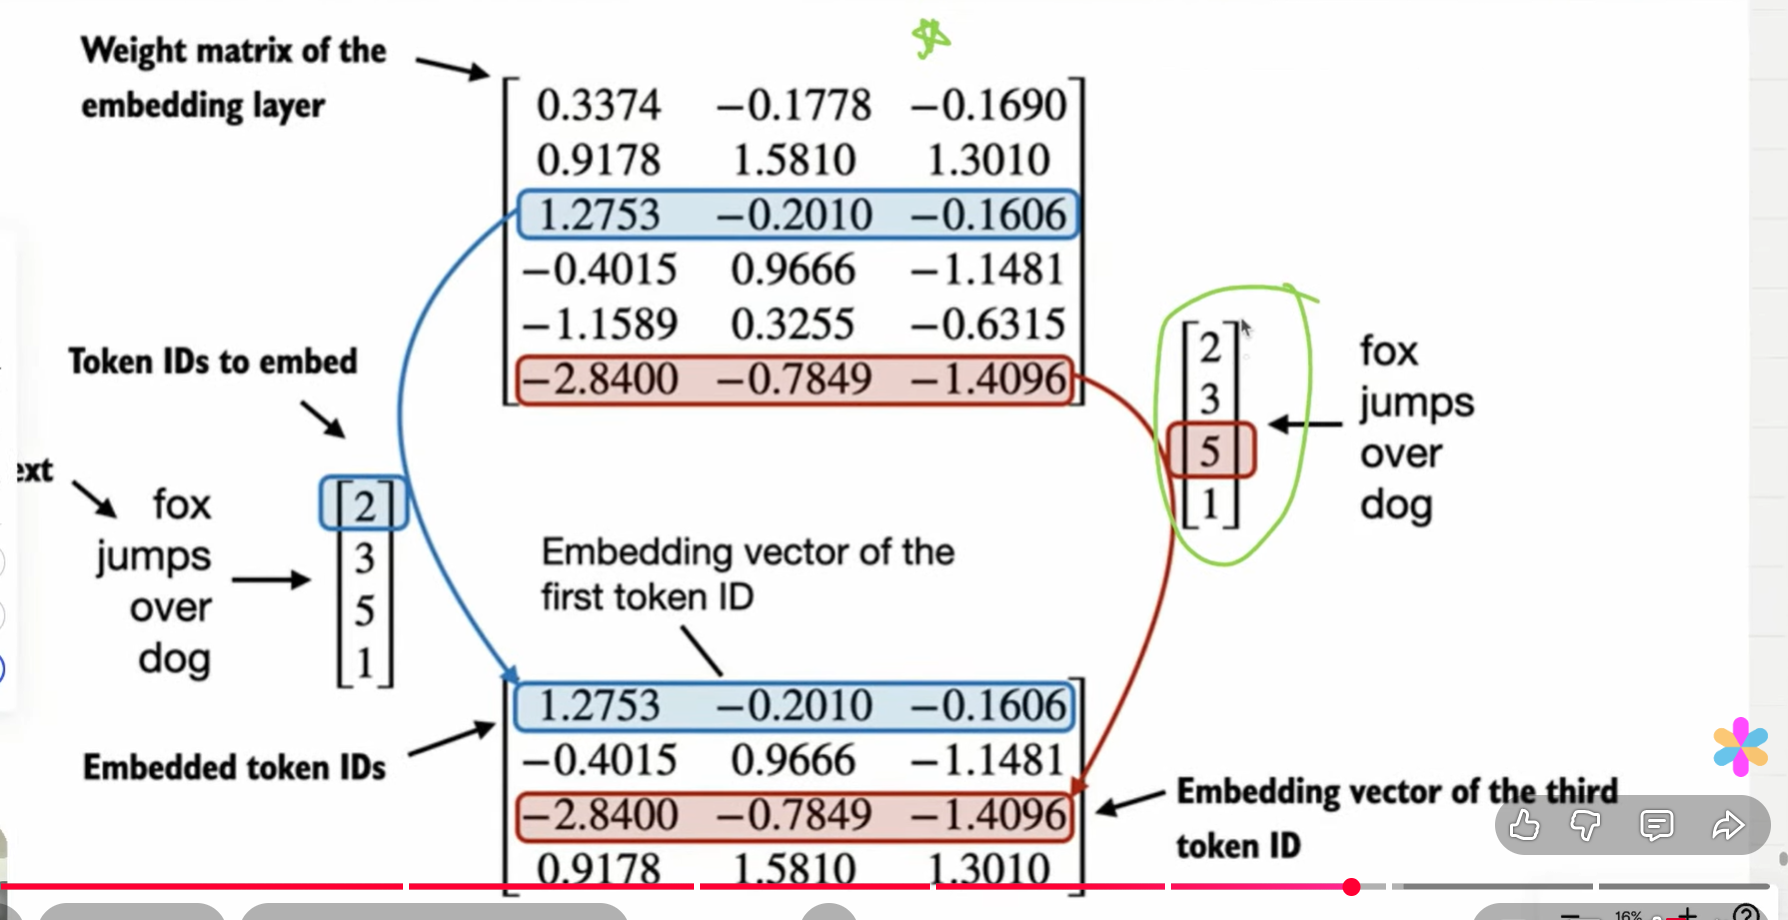

Each row in this output matrix is obtained via a lookup operation from the embedding weight matrix

Positional Emebbding (Encoding Word Positions)

Previously, we focussed on very small embedding sizes in this chapter for illustration purposes

We now consider more realisitc and useful embeddings sizes and encode the input tokens into a 256-dimensional vector representation

This is smaller than what the original GPT-3 model used (in GPT-3, the embedding size is 12,288 dimesions) but still reasonable for experimentation

Furthermore, we assume that the token ID were created by the BPE tokenizer that we implemented earlier, which has a vocabulary size of 50,257

In [ ]:
import torch

In [ ]:
vocab_size = 50257
output_dim = 256
token_embedding_layer = torch.nn.Embedding(vocab_size,output_dim)

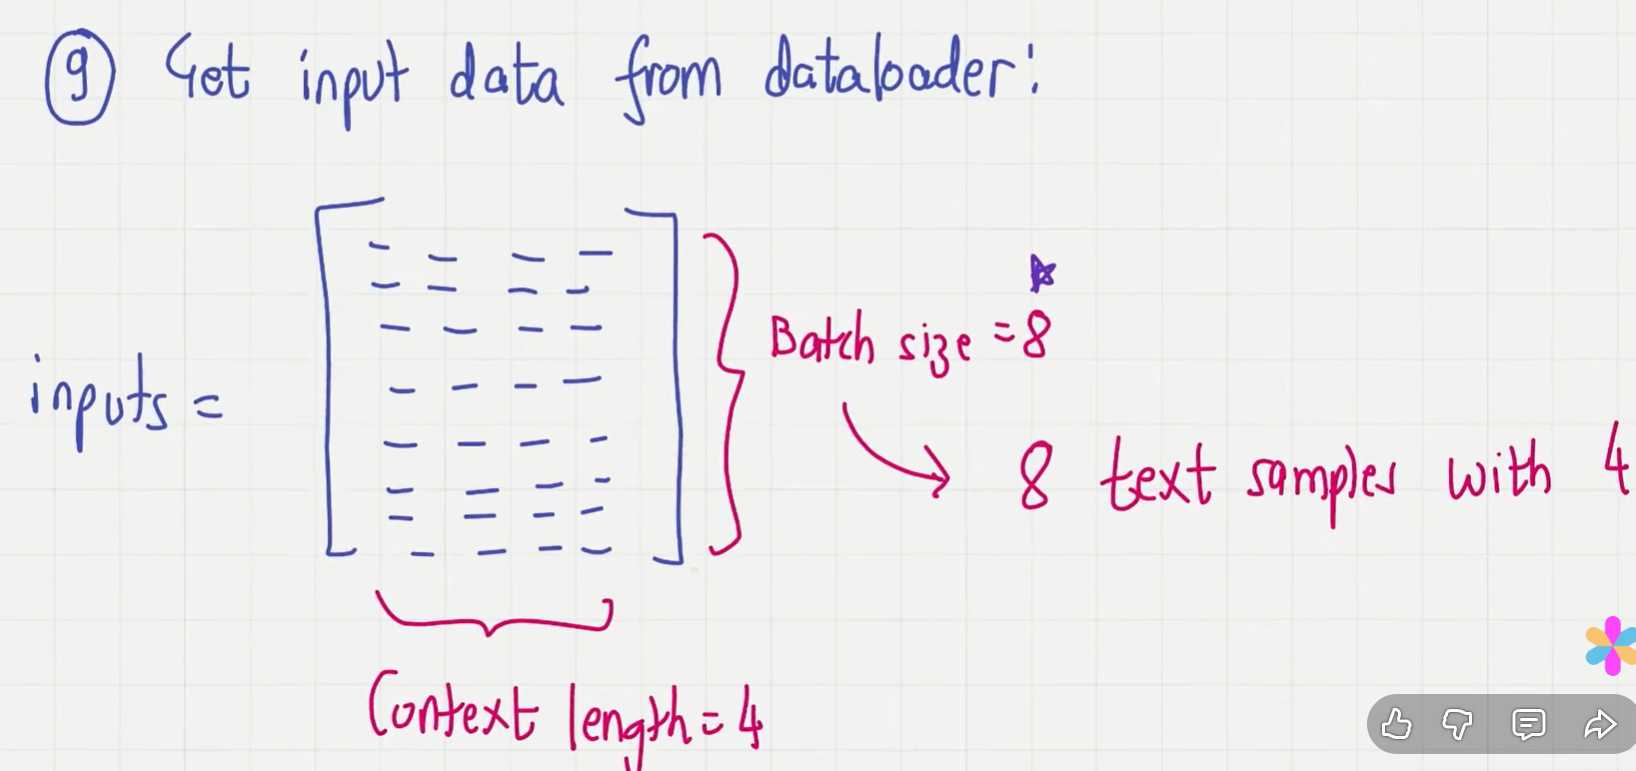

Using the token_embedding_layer above, if we sample data from the data loader, we embed each token in each batch into a 256-dimensional vector. If we have a batch size of 8 with four tokens each, the result will be an 8 x 4 x 256 tensor.

Lets Instantiate the dataloader (data sampling with a sliding window) , first

In [ ]:
max_length = 4
#stride means skips
dataloader = create_datasetloader_v1(raw_text,batch_size=8,max_length=4, stride=max_length,shuffle=False)
#dataloader = create_datasetloader_v1(raw_text,batch_size=8,max_lenth=max_length, stride=max_length, shuffle=False)
data_iter = iter(dataloader)
inputs,targets = next(data_iter)

In [ ]:
print("Token IDs:\n",inputs)
print("\nInputs Shape:\n",targets)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs Shape:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


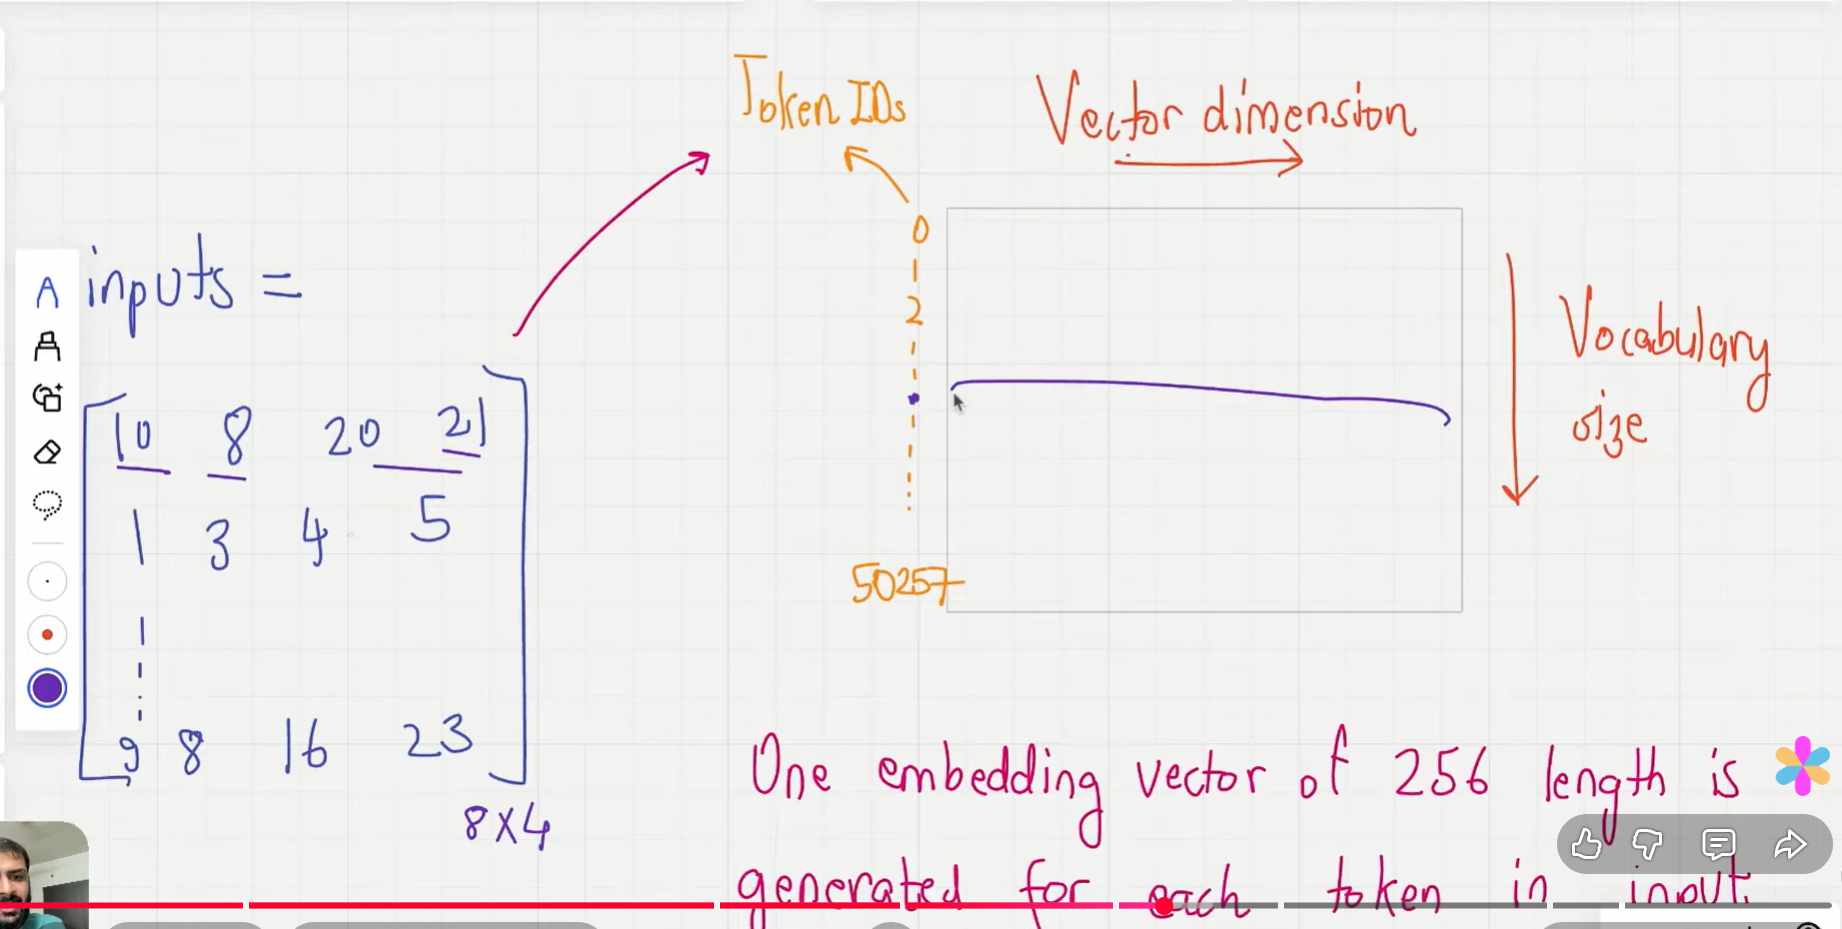

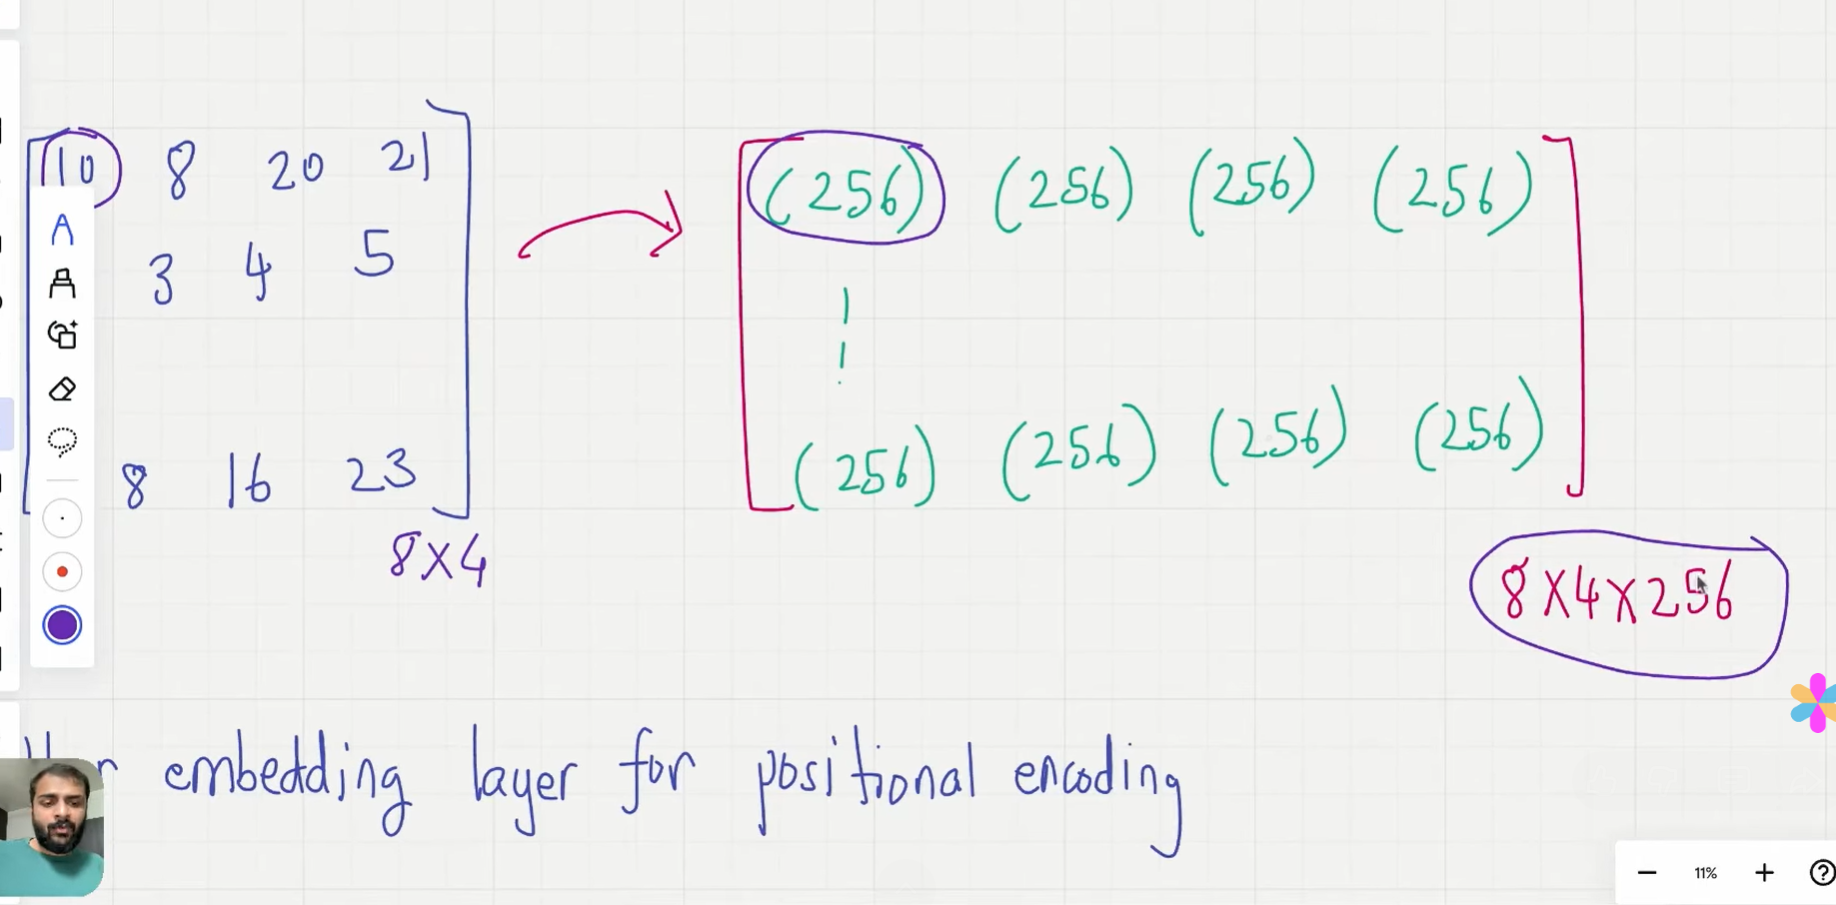

As we can see, the token ID tensor is 8*4 dimensional meaning that the data batch consists of 8 text samples with 4 tokens each

Let's now use the embedding layer to embed these token IDs into 256-dimensional vectors:



In [ ]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings)
print(token_embeddings.shape)

tensor([[[ 0.4913,  1.1239,  1.4588,  ..., -0.3995, -1.8735, -0.1445],
         [ 0.4481,  0.2536, -0.2655,  ...,  0.4997, -1.1991, -1.1844],
         [-0.2507, -0.0546,  0.6687,  ...,  0.9618,  2.3737, -0.0528],
         [ 0.9457,  0.8657,  1.6191,  ..., -0.4544, -0.7460,  0.3483]],

        [[ 1.5460,  1.7368, -0.7848,  ..., -0.1004,  0.8584, -0.3421],
         [-1.8622, -0.1914, -0.3812,  ...,  1.1220, -0.3496,  0.6091],
         [ 1.9847, -0.6483, -0.1415,  ..., -0.3841, -0.9355,  1.4478],
         [ 0.9647,  1.2974, -1.6207,  ...,  1.1463,  1.5797,  0.3969]],

        [[-0.7713,  0.6572,  0.1663,  ..., -0.8044,  0.0542,  0.7426],
         [ 0.8046,  0.5047,  1.2922,  ...,  1.4648,  0.4097,  0.3205],
         [ 0.0795, -1.7636,  0.5750,  ...,  2.1823,  1.8231, -0.3635],
         [ 0.4267, -0.0647,  0.5686,  ..., -0.5209,  1.3065,  0.8473]],

        ...,

        [[-1.6156,  0.9610, -2.6437,  ..., -0.9645,  1.0888,  1.6383],
         [-0.3985, -0.9235, -1.3163,  ..., -1.1582, -1.13

As we can tell based on the 8x4x256-dimensional tensor output, each token ID is now embedded as a 256-dimensional vector.

For a GPT model's absoulte embedding approach, we just need to create another embedding layer that has the same dimension as the token_embedding_layer

In [ ]:
# here is the number of rows is the context length
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length,output_dim)
print(pos_embedding_layer)

Embedding(4, 256)


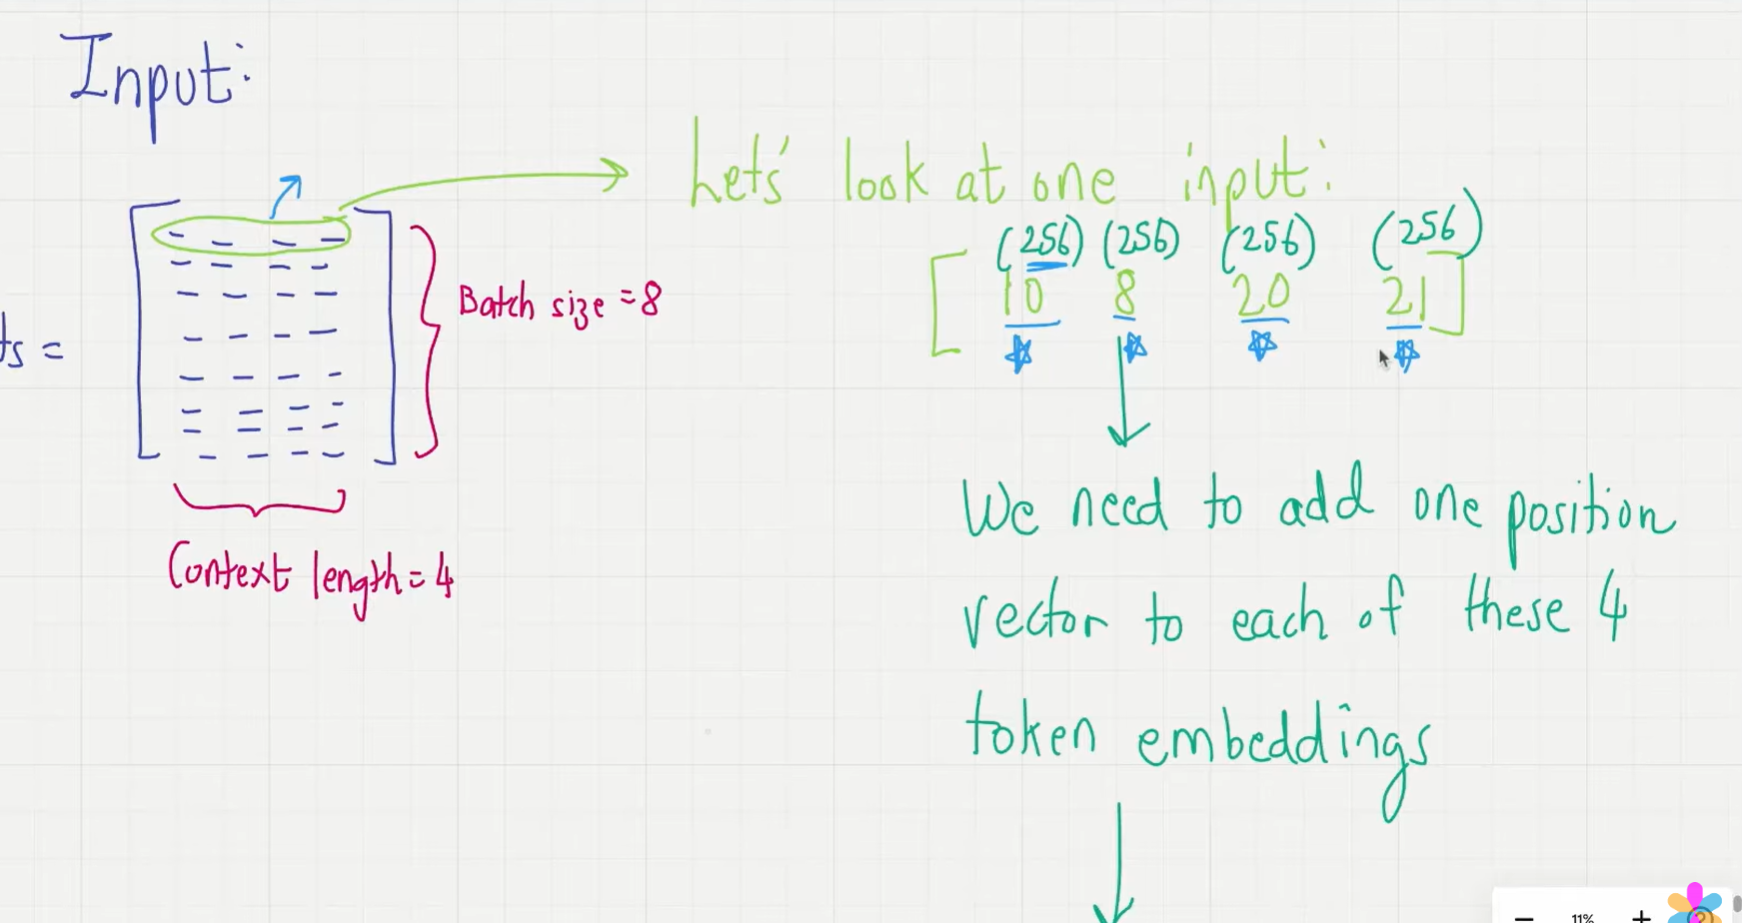

In [ ]:
pos_embedding = pos_embedding_layer(torch.arange(max_length))

In [ ]:
print(pos_embedding)

tensor([[-0.7261, -0.0688, -0.7009,  ..., -0.0921, -0.1557,  2.3573],
        [-0.8398,  0.2168,  1.0688,  ...,  0.3542, -1.1738,  1.0604],
        [ 0.9218, -0.1852, -1.0204,  ...,  0.0693, -0.5336,  0.7380],
        [-1.0855,  1.0690, -1.4043,  ..., -0.6755, -1.2119,  2.2913]],
       grad_fn=<EmbeddingBackward0>)


As showin in the preceding code example, the input to the pos_embedding is usually placeholder vector torch.arange(context_lenght) , which contains a sequence of numbers 0,1,-- up to the maximum input length -1

The context length is a variable that represents the supported input size of the LLM

here, we chose it similar to the maximum length of the input text

In practise input text can be longer than the supported context length, in which case we have to truncate the text

As we can see, the positonal embedding tensor consists of four 256 dimensional vectors. we can now add these directly to the token embedding, where pytorch will add these directly to the token embeddings, where pytorch will add the 4*256- dimensional pos_embeddings tnesor to each 4*256- dimensional token embedding tensor in each of the 8 batches

In [ ]:
input_embeddings = token_embeddings + pos_embedding
print(input_embeddings.shape)

torch.Size([8, 4, 256])
